In [1]:
##Libraries to run the tools##
# libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("test-angle-equil10.dat", sep='\s+', names= ['angle','E2E'])

In [3]:
df

,angle,E2E
0,126.118950,100.405835
1,58.033682,57.828834
2,136.701208,104.034632
3,158.822412,130.021431
4,126.014203,112.454289
...,...,...
127027,73.796558,50.935906
127028,48.092046,28.886569
127029,59.333691,35.513214
127030,60.212733,46.469309


In [20]:
##ax = sns.histplot(df["E2E"])

<Figure size 1000x600 with 0 Axes>

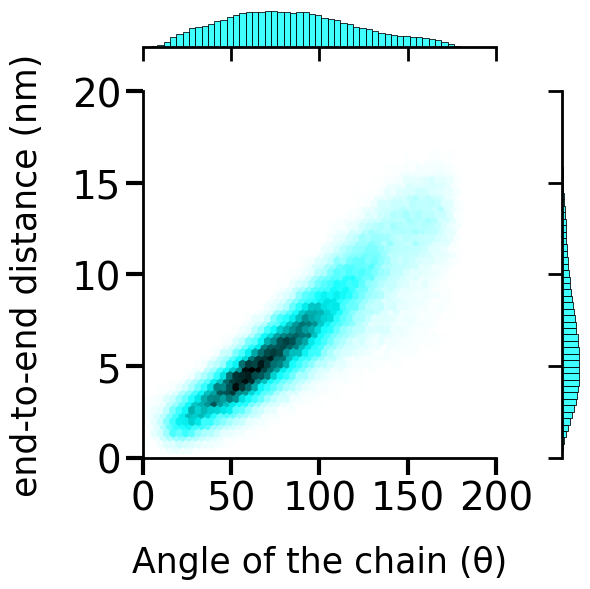

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pylab import rc

## final plot of SASA CG & AA data ##
fig = plt.figure(1034, figsize=(10,6))
rc('axes', linewidth=2.0)

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])
g = sns.jointplot(
    x=df_clean["angle"],
    y=df_clean["E2E"] * 0.10,
    kind='hex',
    color='cyan',
    marginal_kws=dict(bins=50, fill=True)
)

# Get hexbin object and extract density data
hb = g.ax_joint.collections[0]
verts = hb.get_offsets()  # center of each hex
counts = hb.get_array()   # density value at each hex

# Save density data to a CSV file
density_data = pd.DataFrame({
    "angle": verts[:, 0],
    "E2E": verts[:, 1],
    "density": counts
})
density_data.to_csv("hex_density_data.csv", index=False)

## Change the axis label, fontsize, and tick size ##
g.ax_joint.set_xlabel('Angle of the chain (θ)', fontsize=25, labelpad=20, fontname='sans-serif')
g.ax_joint.set_ylabel('end-to-end distance (nm)', fontsize=25, labelpad=20, fontname='sans-serif')

# Axis limits
g.ax_joint.set_xlim([0.0, 200])
g.ax_joint.set_ylim([0.0, 20.0])

# Tick labels bigger
g.ax_joint.set_xticks(np.arange(0, 200.01, 50))
g.ax_joint.set_yticks(np.arange(0, 20.01, 5))
g.ax_joint.tick_params(axis='both', which='major', labelsize=28, direction='out', length=12, width=3)

# Make marginal histograms’ ticks bigger too
g.ax_marg_x.tick_params(axis='x', labelsize=20, direction='out', length=10, width=2)
g.ax_marg_y.tick_params(axis='y', labelsize=20, direction='out', length=10, width=2)

plt.tight_layout()
plt.savefig('E2E-angle-40per-pluronic-300K.png', dpi=400)
plt.show()

<Figure size 1000x600 with 0 Axes>

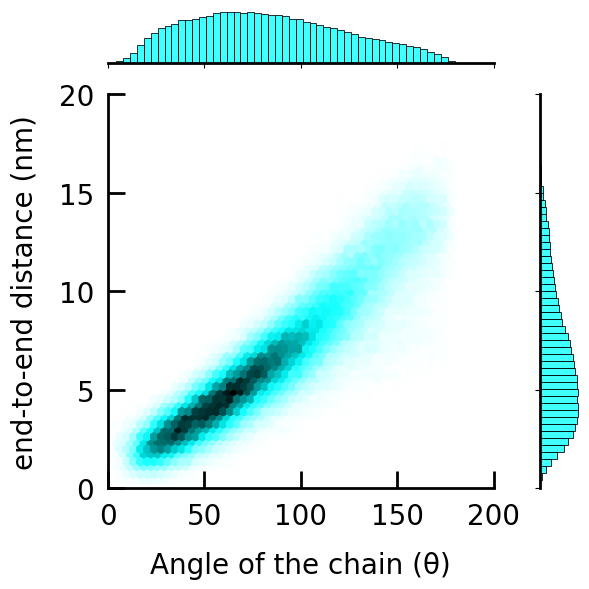

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
##df = sns.load_dataset('iris')

## final plot of SASA CG & AA data ##
fig = plt.figure(1034, figsize=(10,6))
from pylab import*
rc('axes', linewidth=2.0)

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])
g = sns.jointplot(x=df_clean["angle"], y=df_clean["E2E"]*0.10, kind='hex', color='cyan', marginal_kws=dict(bins=50, fill=True))

# Get hexbin object and extract density data
hb = g.ax_joint.collections[0]
verts = hb.get_offsets()  # center of each hex
counts = hb.get_array()   # density value at each hex

# Save density data to a CSV file
density_data = pd.DataFrame({
    "angle": verts[:, 0],
    "E2E": verts[:, 1],
    "density": counts
})
density_data.to_csv("hex_density_data.csv", index=False)

##change the axis lable, fontsize and lable size of the plot## 
plt.ylabel('end-to-end distance (nm)', fontsize=20, labelpad=15, fontname='sans-serif')
plt.xlabel('Angle of the chain (\u03B8)', fontsize=20, labelpad=15, fontname='sans-serif')
plt.ylim([0.0, 20.0])
plt.yticks(np.arange(0, 20.01, 5), fontsize=25, fontname='sans-serif')
plt.xlim([0.0, 200])
plt.xticks(np.arange(0.0, 200.01, 50), fontsize=25, fontname='sans-serif')

##plt.legend(fontsize=15, bbox_to_anchor=(0.95,0.95), loc='upper right', edgecolor='white')
plt.tick_params(axis='both', which='major', labelsize=20, direction='in', length=12, pad=10, bottom='bool', left='bool', width=2)

# Remove white space, save and show
plt.tight_layout()
plt.savefig('E2E-angle-40per-pluronic-equil8-300K.png', dpi=400)
plt.show()

In [5]:
import pandas as pd

# Load the saved CSV
density_data = pd.read_csv("hex_density_data.csv")

# Get the row with the maximum density
max_row = density_data.loc[density_data["density"].idxmax()]

print("Maximum density value:", max_row["density"])
print("Corresponding angle (x):", max_row["angle"])
print("Corresponding E2E (y):", max_row["E2E"])

Maximum density value: 519.0
Corresponding angle (x): 61.82782991500973
Corresponding E2E (y): 4.791654542747931


Mean angle: 92.14
Mean E2E distance: 63.03
Max population in bin: 999999999999999937849939638116397466450525159438967985375725315922685858882365002492855496964043060934899979621894213003182527093908649335762989920701551401238528 points (log count = 162.00)
Bin center at: Angle = 64.54, E2E = 46.53


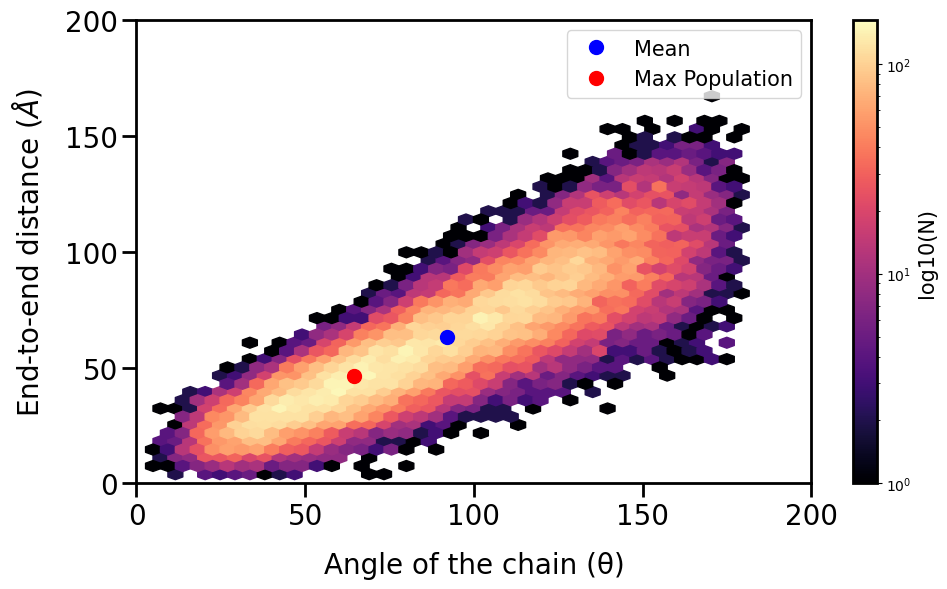

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load and clean data
df = pd.read_csv("test-angle.dat", sep='\s+', names=['angle', 'E2E'])
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])

# Calculate mean values
mean_angle = df_clean['angle'].mean()
mean_e2e = df_clean['E2E'].mean()
print(f"Mean angle: {mean_angle:.2f}")
print(f"Mean E2E distance: {mean_e2e:.2f}")

# Create figure and hexbin plot
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(df_clean["angle"], df_clean["E2E"], gridsize=40, cmap='magma', bins='log', mincnt=1)

# Find bin with max count
counts = hb.get_array()
verts = hb.get_offsets()
max_idx = np.argmax(counts)
max_count = counts[max_idx]
max_location = verts[max_idx]

print(f"Max population in bin: {int(10**max_count)} points (log count = {max_count:.2f})")
print(f"Bin center at: Angle = {max_location[0]:.2f}, E2E = {max_location[1]:.2f}")

# Plot mean point
ax.plot(mean_angle, mean_e2e, 'bo', markersize=10, label='Mean')

# Mark max density point
ax.plot(max_location[0], max_location[1], 'ro', markersize=10, label='Max Population')

# Axis labels and ticks
ax.set_xlabel('Angle of the chain (\u03B8)', fontsize=20, labelpad=15, fontname='sans-serif')
ax.set_ylabel('End-to-end distance ($\AA$)', fontsize=20, labelpad=15, fontname='sans-serif')
ax.set_xlim([0, 200])
ax.set_ylim([0, 200])
ax.set_xticks(np.arange(0, 201, 50))
ax.set_yticks(np.arange(0, 201, 50))
ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=10, width=2)

# Legend and colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label('log10(N)', fontsize=15)
ax.legend(fontsize=15, loc='upper right')

plt.tight_layout()
plt.savefig('E2E-angle-pluronic-new.png', dpi=400)
plt.show()


Max population in bin: 692
Bin center at: Angle = 63.35, E2E = 48.44


/home/sukanya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sukanya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


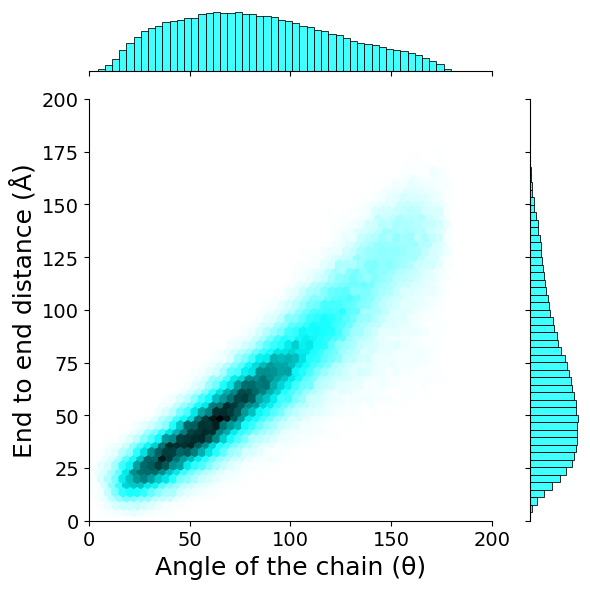

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load and clean data
df = pd.read_csv("test-angle-equil8.dat", sep='\s+', names=['angle', 'E2E'])
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])

# Compute 2D histogram (same as hexbin density behind sns.jointplot(kind='hex'))
x = df_clean['angle']
y = df_clean['E2E']
bins = 50  # Should match seaborn resolution roughly

# Compute histogram
counts, xedges, yedges = np.histogram2d(x, y, bins=bins)

# Find max bin index
max_idx = np.unravel_index(np.argmax(counts), counts.shape)
max_count = counts[max_idx]
max_x_center = (xedges[max_idx[0]] + xedges[max_idx[0]+1]) / 2
max_y_center = (yedges[max_idx[1]] + yedges[max_idx[1]+1]) / 2

print(f"Max population in bin: {int(max_count)}")
print(f"Bin center at: Angle = {max_x_center:.2f}, E2E = {max_y_center:.2f}")

# Create seaborn jointplot
g = sns.jointplot(x=x, y=y, kind='hex', color='cyan', marginal_kws=dict(bins=50, fill=True))

# Overlay max density point
#g.ax_joint.plot(max_x_center, max_y_center, 'gs-', markersize=20, label='Max Density')
#g.ax_joint.legend(fontsize=12)

# Overlay max density point as an unfilled circle
#circle = plt.Circle((max_x_center, max_y_center), radius=dx/2, edgecolor='black', facecolor='none', linewidth=3)
#g.ax_joint.add_patch(circle)

# Customize labels and ticks
g.set_axis_labels('Angle of the chain (θ)', 'End to end distance (Å)', fontsize=18)
g.ax_joint.set_xlim([0, 200])
g.ax_joint.set_ylim([0, 200])
g.ax_joint.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.savefig('E2E-angle-density-sns.png', dpi=400)
plt.show()

/home/sukanya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sukanya/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


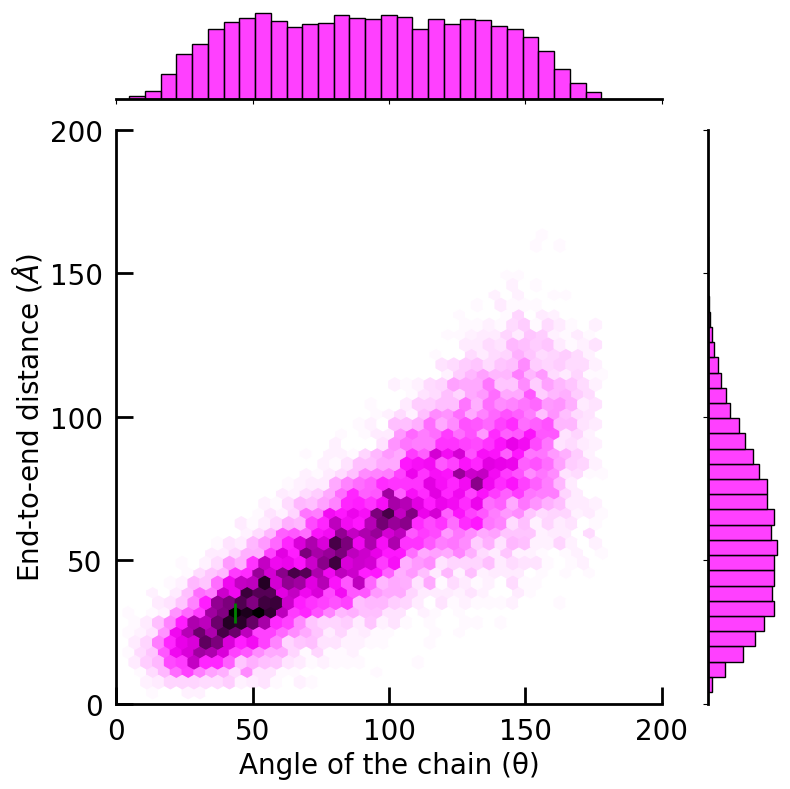

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pylab import rc
rc('axes', linewidth=2.0)

# Clean the data
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["angle", "E2E"])

# Create the jointplot
g = sns.jointplot(
    x="angle", 
    y="E2E", 
    data=df_clean, 
    kind='hex', 
    color='magenta',
    marginal_kws=dict(bins=30, fill=True),
    height=8,
    space=0.2
)

# Get hexbin object and extract density data
hb = g.ax_joint.collections[0]
verts = hb.get_offsets()  # center of each hex
counts = hb.get_array()   # density value at each hex

# Save density data to a CSV file
density_data = pd.DataFrame({
    "angle": verts[:, 0],
    "E2E": verts[:, 1],
    "density": counts
})
density_data.to_csv("hex_density_data.csv", index=False)

# Find the max density location
max_idx = np.argmax(counts)
max_x_center, max_y_center = verts[max_idx]

# Define hexbin size (roughly estimated from the binning)
dx = verts[1, 0] - verts[0, 0]
dy = verts[1, 1] - verts[0, 1]
# Draw a rectangle around the max-density hex
g.ax_joint.add_patch(plt.Rectangle(
    (max_x_center - dx/2, max_y_center - dy/2),
    dx, dy,
    edgecolor='green',
    facecolor='none',
    linewidth=2
))

# Customize axis labels and ticks
g.set_axis_labels(
    'Angle of the chain (\u03B8)', 
    'End-to-end distance ($\AA$)',
    fontsize=20
)
g.ax_joint.tick_params(
    axis='both', which='major', labelsize=20, direction='in', 
    length=12, pad=10, bottom=True, left=True, width=2
)
g.ax_joint.set_xlim([0.0, 200])
g.ax_joint.set_ylim([0.0, 200])
g.ax_joint.set_xticks(np.arange(0, 201, 50))
g.ax_joint.set_yticks(np.arange(0, 201, 50))
g.ax_joint.set_xticklabels(np.arange(0, 201, 50), fontname='sans-serif')
g.ax_joint.set_yticklabels(np.arange(0, 201, 50), fontname='sans-serif')

# Save and show the plot
plt.tight_layout()
plt.savefig('new.png', dpi=400)
plt.show()
